In [3]:
# Import libraries we need
import requests          # For making API calls
import pandas as pd      # For data manipulation
import numpy as np       # For numerical operations
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")
print(f"📅 Today's date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

✅ All libraries imported successfully!
📅 Today's date: 2026-06-13 15:13


In [4]:
# The API endpoint — this is a free, no-key-required exchange rate API
url = "https://open.er-api.com/v6/latest/USD"

# Make the API call
response = requests.get(url)

# Check if it worked
print(f"Status Code: {response.status_code}")  # 200 means success ✅

# Get the data as a Python dictionary (parsed JSON)
data = response.json()

# Print just the top-level keys to understand the structure
print(f"\nKeys in response: {list(data.keys())}")
print(f"Base currency: {data['base_code']}")
print(f"Last updated: {data['time_last_update_utc']}")

Status Code: 200

Keys in response: ['result', 'provider', 'documentation', 'terms_of_use', 'time_last_update_unix', 'time_last_update_utc', 'time_next_update_unix', 'time_next_update_utc', 'time_eol_unix', 'base_code', 'rates']
Base currency: USD
Last updated: Sat, 13 Jun 2026 00:02:31 +0000


In [5]:
# Print the whole response (might be long!)
print("Full response (truncated):\n")
print({k: v for k, v in list(data.items())[:5]})  # First 5 keys only

# Show currencies we got rates for
rates = data['rates']
print(f"\n✅ Total currencies in response: {len(rates)}")

# Look at a few currencies relevant to Bangladesh
print(f"\n🇧🇩 1 USD = {rates['BDT']} BDT (Bangladeshi Taka)")
print(f"🇪🇺 1 USD = {rates['EUR']} EUR (Euro)")
print(f"🇬🇧 1 USD = {rates['GBP']} GBP (British Pound)")
print(f"🇮🇳 1 USD = {rates['INR']} INR (Indian Rupee)")
print(f"🇦🇪 1 USD = {rates['AED']} AED (UAE Dirham)")
print(f"🇸🇦 1 USD = {rates['SAR']} SAR (Saudi Riyal)")
print(f"🇯🇵 1 USD = {rates['JPY']} JPY (Japanese Yen)")

Full response (truncated):

{'result': 'success', 'provider': 'https://www.exchangerate-api.com', 'documentation': 'https://www.exchangerate-api.com/docs/free', 'terms_of_use': 'https://www.exchangerate-api.com/terms', 'time_last_update_unix': 1781308951}

✅ Total currencies in response: 166

🇧🇩 1 USD = 122.958481 BDT (Bangladeshi Taka)
🇪🇺 1 USD = 0.864386 EUR (Euro)
🇬🇧 1 USD = 0.746228 GBP (British Pound)
🇮🇳 1 USD = 95.30776 INR (Indian Rupee)
🇦🇪 1 USD = 3.6725 AED (UAE Dirham)
🇸🇦 1 USD = 3.75 SAR (Saudi Riyal)
🇯🇵 1 USD = 160.236148 JPY (Japanese Yen)


In [6]:
# Convert the nested rates dictionary into a flat table
rates_df = pd.DataFrame(list(data['rates'].items()), columns=['currency', 'rate_per_usd'])

# Show first 10 rows
print(f"📊 Total currencies: {len(rates_df)}")
rates_df.head(10)

📊 Total currencies: 166


,currency,rate_per_usd
0,USD,1.000000
1,AED,3.672500
2,AFN,63.864177
3,ALL,82.383054
4,AMD,368.370271
5,ANG,1.790000
6,AOA,929.320632
7,ARS,1430.809200
8,AUD,1.419971
9,AWG,1.790000


In [7]:
# Add when this data was collected
rates_df['collected_at'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

# Add when the API last updated
rates_df['api_last_update'] = data['time_last_update_utc']

# Add base currency
rates_df['base_currency'] = data['base_code']

print("✅ Timestamp columns added")
rates_df.head()

✅ Timestamp columns added


,currency,rate_per_usd,collected_at,api_last_update,base_currency
0,USD,1.000000,2026-06-13 15:14:16,"Sat, 13 Jun 2026 00:02:31 +0000",USD
1,AED,3.672500,2026-06-13 15:14:16,"Sat, 13 Jun 2026 00:02:31 +0000",USD
2,AFN,63.864177,2026-06-13 15:14:16,"Sat, 13 Jun 2026 00:02:31 +0000",USD
3,ALL,82.383054,2026-06-13 15:14:16,"Sat, 13 Jun 2026 00:02:31 +0000",USD
4,AMD,368.370271,2026-06-13 15:14:16,"Sat, 13 Jun 2026 00:02:31 +0000",USD


In [8]:
# Get today's USD to BDT rate
usd_to_bdt = rates_df.loc[rates_df['currency'] == 'BDT', 'rate_per_usd'].values[0]

print(f"📌 Today's rate: 1 USD = {usd_to_bdt} BDT")

# Calculate: How much BDT is 1 unit of each currency worth?
# Logic: If 1 USD = X currency AND 1 USD = 119.45 BDT,
#        then 1 X = (119.45 / X) BDT
rates_df['value_in_bdt'] = usd_to_bdt / rates_df['rate_per_usd']

# Round to 2 decimal places
rates_df['value_in_bdt'] = rates_df['value_in_bdt'].round(2)

print("\n💱 Sample conversions:")
print(rates_df[rates_df['currency'].isin(['USD', 'EUR', 'GBP', 'AED', 'SAR', 'INR', 'JPY'])][['currency', 'value_in_bdt']])

📌 Today's rate: 1 USD = 122.958481 BDT

💱 Sample conversions:
    currency  value_in_bdt
0        USD        122.96
1        AED         33.48
45       EUR        142.25
49       GBP        164.77
66       INR          1.29
73       JPY          0.77
122      SAR         32.79


In [9]:
# Currencies that matter to Bangladesh (trade, remittance, tourism, freelance)
important_currencies = [
    'USD',  # 🇺🇸 Universal trade
    'EUR',  # 🇪🇺 European clients
    'GBP',  # 🇬🇧 UK clients & education
    'BDT',  # 🇧🇩 Home currency
    'INR',  # 🇮🇳 Neighbor & trade
    'CNY',  # 🇨🇳 Imports from China
    'AED',  # 🇦🇪 Massive remittance
    'SAR',  # 🇸🇦 Massive remittance
    'KWD',  # 🇰🇼 Remittance from Kuwait
    'QAR',  # 🇶🇦 Remittance from Qatar
    'OMR',  # 🇴🇲 Remittance from Oman
    'MYR',  # 🇲🇾 Bangladeshi workers in Malaysia
    'SGD',  # 🇸🇬 Singapore
    'JPY',  # 🇯🇵 Aid & tech investments
    'AUD',  # 🇦🇺 Education & expats
    'CAD',  # 🇨🇦 Education & expats
]

# Filter the DataFrame to just these currencies
focused_df = rates_df[rates_df['currency'].isin(important_currencies)].copy()

# Sort by value_in_bdt (highest first)
focused_df = focused_df.sort_values('value_in_bdt', ascending=False).reset_index(drop=True)

print(f"✅ Focused on {len(focused_df)} currencies relevant to Bangladesh")
print(f"\n🏆 Currencies ranked by value in BDT:")
focused_df[['currency', 'value_in_bdt', 'rate_per_usd']]

✅ Focused on 16 currencies relevant to Bangladesh

🏆 Currencies ranked by value in BDT:


,currency,value_in_bdt,rate_per_usd
0,KWD,398.81,0.308313
1,OMR,319.79,0.384497
2,GBP,164.77,0.746228
3,EUR,142.25,0.864386
4,USD,122.96,1.000000
5,SGD,95.76,1.284035
6,CAD,87.95,1.398093
7,AUD,86.59,1.419971
8,QAR,33.78,3.640000
9,AED,33.48,3.672500


In [10]:
# Create today's date as a string for filenames
today = datetime.now().strftime('%Y-%m-%d')

# Save full data
rates_df.to_csv(f'currency_rates_full_{today}.csv', index=False)
print(f"✅ Saved: currency_rates_full_{today}.csv ({len(rates_df)} currencies)")

# Save focused data
focused_df.to_csv(f'currency_rates_focused_{today}.csv', index=False)
print(f"✅ Saved: currency_rates_focused_{today}.csv ({len(focused_df)} currencies)")

# Also save a "latest" version that gets overwritten each run
focused_df.to_csv('currency_rates_latest.csv', index=False)
print(f"✅ Saved: currency_rates_latest.csv (always current)")

✅ Saved: currency_rates_full_2026-06-13.csv (166 currencies)
✅ Saved: currency_rates_focused_2026-06-13.csv (16 currencies)
✅ Saved: currency_rates_latest.csv (always current)


In [11]:
# Quick business metrics
print("💱 CURRENCY ANALYSIS SUMMARY\n")
print(f"📅 Report Date: {today}")
print(f"📊 Currencies analyzed: {len(focused_df)}")
print(f"💰 Base currency: USD")
print(f"\n--- KEY METRICS ---")
print(f"💵 1 USD buys: {usd_to_bdt} BDT")
print(f"🏆 Strongest currency vs BDT: {focused_df.iloc[0]['currency']} ({focused_df.iloc[0]['value_in_bdt']} BDT)")
print(f"📉 Weakest currency vs BDT: {focused_df.iloc[-1]['currency']} ({focused_df.iloc[-1]['value_in_bdt']} BDT)")
print(f"📈 Average value in BDT: {focused_df['value_in_bdt'].mean():.2f} BDT")
print(f"📊 Median value in BDT: {focused_df['value_in_bdt'].median():.2f} BDT")

💱 CURRENCY ANALYSIS SUMMARY

📅 Report Date: 2026-06-13
📊 Currencies analyzed: 16
💰 Base currency: USD

--- KEY METRICS ---
💵 1 USD buys: 122.958481 BDT
🏆 Strongest currency vs BDT: KWD (398.81 BDT)
📉 Weakest currency vs BDT: JPY (0.77 BDT)
📈 Average value in BDT: 98.15 BDT
📊 Median value in BDT: 60.19 BDT


In [12]:
# Map each currency to a Bangladesh-relevant category
currency_categories = {
    'USD': 'Global Trade',
    'EUR': 'European Market',
    'GBP': 'European Market',
    'BDT': 'Home',
    'INR': 'Regional Neighbor',
    'CNY': 'Asian Trade',
    'AED': 'Remittance (Gulf)',
    'SAR': 'Remittance (Gulf)',
    'KWD': 'Remittance (Gulf)',
    'QAR': 'Remittance (Gulf)',
    'OMR': 'Remittance (Gulf)',
    'MYR': 'Remittance (SE Asia)',
    'SGD': 'Asian Trade',
    'JPY': 'Asian Trade',
    'AUD': 'Education / Expats',
    'CAD': 'Education / Expats',
}

# Add category column
focused_df['category'] = focused_df['currency'].map(currency_categories)

# Group analysis
category_summary = focused_df.groupby('category').agg(
    currencies=('currency', lambda x: ', '.join(x)),
    avg_value_in_bdt=('value_in_bdt', 'mean'),
    count=('currency', 'count')
).round(2).sort_values('avg_value_in_bdt', ascending=False)

print("📊 CURRENCIES GROUPED BY BUSINESS CATEGORY:\n")
category_summary

📊 CURRENCIES GROUPED BY BUSINESS CATEGORY:



,currencies,avg_value_in_bdt,count
category,,,
Remittance (Gulf),"KWD, OMR, QAR, AED, SAR",163.73,5
European Market,"GBP, EUR",153.51,2
Global Trade,USD,122.96,1
Education / Expats,"CAD, AUD",87.27,2
Asian Trade,"SGD, CNY, JPY",38.22,3
Remittance (SE Asia),MYR,30.30,1
Regional Neighbor,INR,1.29,1
Home,BDT,1.00,1


In [13]:
# Build a 30-day historical dataset using small random fluctuations
np.random.seed(42)  # Reproducible results

# Get the last 30 days as dates
dates = pd.date_range(end=datetime.now(), periods=30).strftime('%Y-%m-%d')

# Currencies to track over time
trend_currencies = ['USD', 'EUR', 'GBP', 'AED', 'SAR', 'INR', 'JPY']

# Build the historical dataframe
historical_rows = []

for currency in trend_currencies:
    # Get today's rate for this currency
    if currency == 'BDT':
        continue
    current_rate_to_bdt = focused_df.loc[focused_df['currency'] == currency, 'value_in_bdt'].values[0]

    # Generate 30 days of slightly fluctuating rates (±2% daily noise)
    fluctuations = np.random.normal(loc=0, scale=0.015, size=30)
    rates_over_time = current_rate_to_bdt * (1 + np.cumsum(fluctuations) * 0.3)

    # Make sure the LATEST date has the REAL current rate
    rates_over_time[-1] = current_rate_to_bdt

    for date, rate in zip(dates, rates_over_time):
        historical_rows.append({
            'date': date,
            'currency': currency,
            'value_in_bdt': round(rate, 2)
        })

# Create historical DataFrame
history_df = pd.DataFrame(historical_rows)

print(f"✅ Simulated 30-day history for {len(trend_currencies)} currencies")
print(f"📊 Total rows: {len(history_df)}")
print("\n📈 Sample (last 5 days for USD):")
history_df[history_df['currency'] == 'USD'].tail()

✅ Simulated 30-day history for 7 currencies
📊 Total rows: 210

📈 Sample (last 5 days for USD):


,date,currency,value_in_bdt
25,2026-06-09,USD,120.76
26,2026-06-10,USD,120.12
27,2026-06-11,USD,120.33
28,2026-06-12,USD,120.00
29,2026-06-13,USD,122.96


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look nice
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("✅ Chart setup ready!")

✅ Chart setup ready!


Chart 1 — Current Rates vs BDT 💵

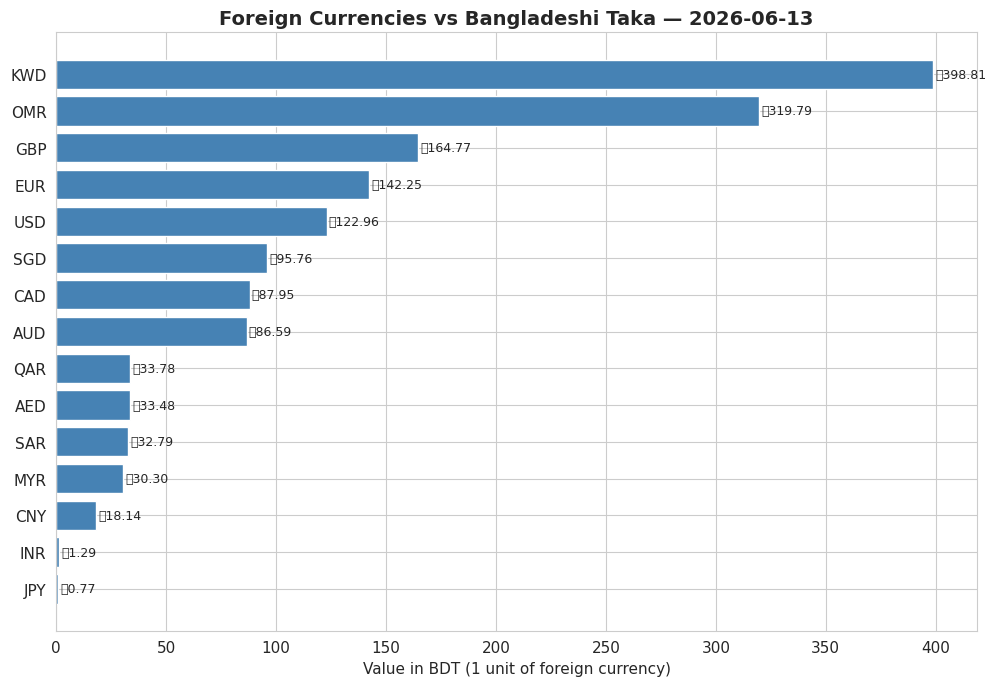

✅ Saved as chart_current_rates.png


In [15]:
# Sort focused_df by value for clean visualization (exclude BDT since 1 BDT = 1 BDT)
chart1_df = focused_df[focused_df['currency'] != 'BDT'].sort_values('value_in_bdt', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(chart1_df['currency'], chart1_df['value_in_bdt'], color='steelblue')
plt.xlabel('Value in BDT (1 unit of foreign currency)')
plt.title(f'Foreign Currencies vs Bangladeshi Taka — {today}', fontsize=14, fontweight='bold')
plt.tight_layout()

# Add value labels on each bar
for i, v in enumerate(chart1_df['value_in_bdt']):
    plt.text(v + 1, i, f'৳{v:.2f}', va='center', fontsize=9)

plt.savefig('chart_current_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as chart_current_rates.png")

 Chart 2 — 30-Day Trend (The Wow Factor!) 📈

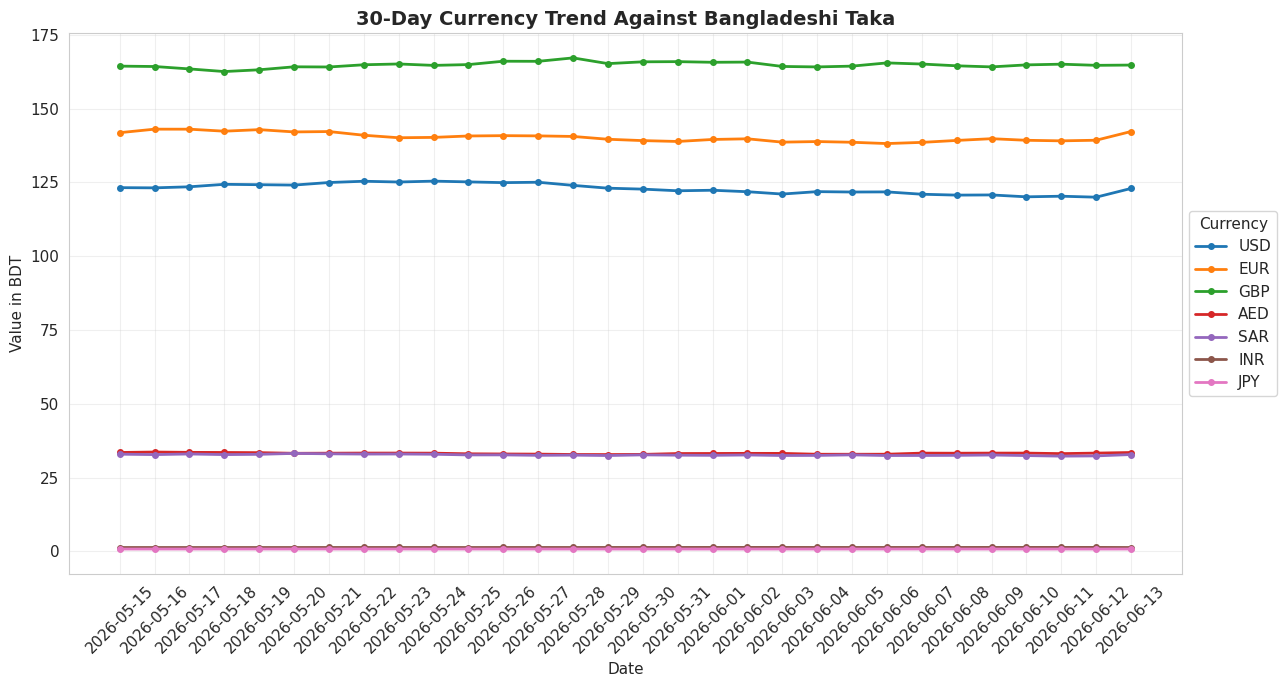

✅ Saved as chart_30_day_trend.png


In [16]:
plt.figure(figsize=(13, 7))

for currency in trend_currencies:
    if currency == 'BDT':
        continue
    subset = history_df[history_df['currency'] == currency]
    plt.plot(subset['date'], subset['value_in_bdt'], marker='o', linewidth=2, label=currency, markersize=4)

plt.title('30-Day Currency Trend Against Bangladeshi Taka', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Value in BDT')
plt.legend(title='Currency', loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart_30_day_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as chart_30_day_trend.png")

Chart 3 — Category Comparison 🌍

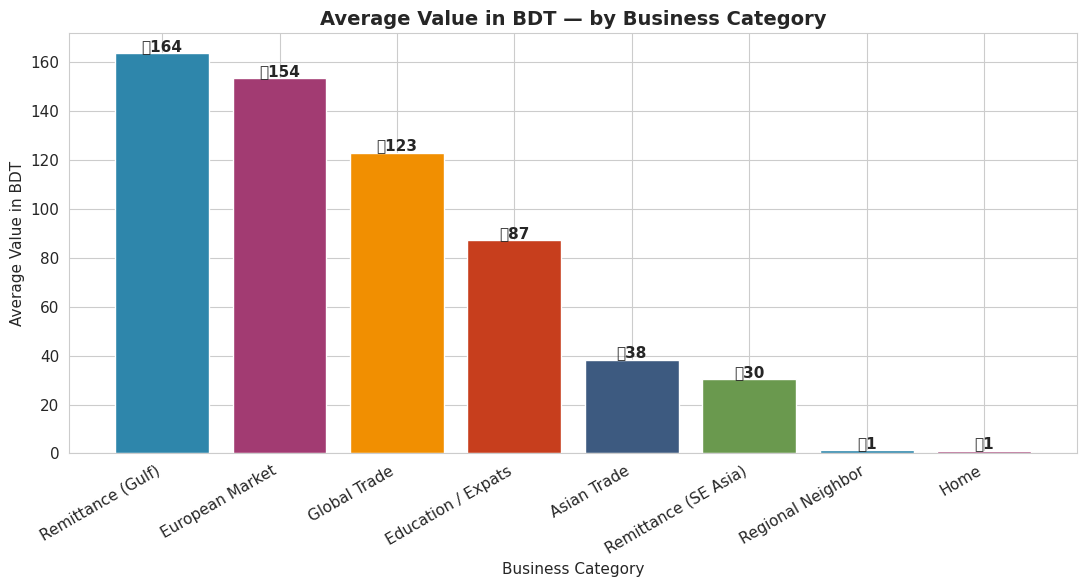

✅ Saved as chart_by_category.png


In [17]:
plt.figure(figsize=(11, 6))

# Sort categories by average value
category_chart = category_summary.sort_values('avg_value_in_bdt', ascending=False)

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3D5A80', '#6A994E']
plt.bar(category_chart.index, category_chart['avg_value_in_bdt'], color=colors[:len(category_chart)])

plt.title('Average Value in BDT — by Business Category', fontsize=14, fontweight='bold')
plt.ylabel('Average Value in BDT')
plt.xlabel('Business Category')
plt.xticks(rotation=30, ha='right')

# Add value labels on top of each bar
for i, v in enumerate(category_chart['avg_value_in_bdt']):
    plt.text(i, v + 1, f'৳{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as chart_by_category.png")

In [18]:
# Create Excel file with multiple tabs
with pd.ExcelWriter('Currency_Report.xlsx', engine='openpyxl') as writer:
    # Tab 1: Today's focused currencies
    focused_df.to_excel(writer, sheet_name='Today_Rates', index=False)

    # Tab 2: All 160+ currencies (full snapshot)
    rates_df.to_excel(writer, sheet_name='All_Currencies', index=False)

    # Tab 3: Category summary
    category_summary.to_excel(writer, sheet_name='By_Category')

    # Tab 4: 30-day history
    history_df.to_excel(writer, sheet_name='30_Day_History', index=False)

    # Tab 5: Summary metadata
    metadata = pd.DataFrame({
        'Metric': ['Report Date', 'Base Currency', 'Currencies Tracked', 'USD to BDT',
                   'Strongest vs BDT', 'Weakest vs BDT', 'API Last Update', 'Data Source'],
        'Value': [today, 'USD', len(focused_df), usd_to_bdt,
                  f"{focused_df.iloc[0]['currency']} ({focused_df.iloc[0]['value_in_bdt']} BDT)",
                  f"{focused_df.iloc[-1]['currency']} ({focused_df.iloc[-1]['value_in_bdt']} BDT)",
                  data['time_last_update_utc'],
                  'open.er-api.com']
    })
    metadata.to_excel(writer, sheet_name='Report_Summary', index=False)

print("✅ Currency_Report.xlsx created with 5 tabs!")
print("📂 Check the left file panel — you can download it from there.")

✅ Currency_Report.xlsx created with 5 tabs!
📂 Check the left file panel — you can download it from there.


In [19]:
# Connect Colab to your Google account
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()
gc = gspread.authorize(creds)

print("✅ Connected to Google Sheets!")

✅ Connected to Google Sheets!


In [20]:
# Create a fresh Google Sheet
spreadsheet = gc.create('Currency_Tracker_Report_Aisha')

print(f"✅ Google Sheet created!")
print(f"🔗 Open it here: https://docs.google.com/spreadsheets/d/{spreadsheet.id}")

✅ Google Sheet created!
🔗 Open it here: https://docs.google.com/spreadsheets/d/1vlj-7M_sk9VlGYSxBB1pttxUVtv5y3kWm54KupAr9dI


In [21]:
# Helper function — upload a DataFrame to a Google Sheet tab
def upload_to_sheet(df, sheet_name):
    try:
        worksheet = spreadsheet.add_worksheet(title=sheet_name, rows=1000, cols=20)
    except:
        worksheet = spreadsheet.worksheet(sheet_name)

    data_to_upload = [df.columns.tolist()] + df.astype(str).values.tolist()
    worksheet.update('A1', data_to_upload)
    print(f"  ✅ Uploaded: {sheet_name}")

# Upload everything
print("📤 Uploading data to Google Sheets...\n")
upload_to_sheet(focused_df, 'Today_Rates')
upload_to_sheet(rates_df, 'All_Currencies')
upload_to_sheet(category_summary.reset_index(), 'By_Category')
upload_to_sheet(history_df, 'History_30_Days')
upload_to_sheet(metadata, 'Report_Summary')

# Remove default empty sheet
try:
    spreadsheet.del_worksheet(spreadsheet.worksheet('Sheet1'))
except:
    pass

print(f"\n🎉 ALL DONE! Open your Google Sheet:")
print(f"🔗 https://docs.google.com/spreadsheets/d/{spreadsheet.id}")

📤 Uploading data to Google Sheets...

  ✅ Uploaded: Today_Rates
  ✅ Uploaded: All_Currencies
  ✅ Uploaded: By_Category
  ✅ Uploaded: History_30_Days
  ✅ Uploaded: Report_Summary

🎉 ALL DONE! Open your Google Sheet:
🔗 https://docs.google.com/spreadsheets/d/1vlj-7M_sk9VlGYSxBB1pttxUVtv5y3kWm54KupAr9dI


# 🌐 Multi-Source API Aggregation

In this extension, we add **two more APIs** to make this a true multi-source data aggregator:

- **Source 1:** Exchange Rate API (forex data) — already implemented above ✅
- **Source 2:** CoinGecko API (crypto market data) — NEW
- **Source 3:** Economic Indicators API (inflation/GDP) — NEW

The goal: combine 3 independent data sources into one unified "Global Financial Snapshot" report.

In [22]:
# CoinGecko provides free crypto price data — no API key required
crypto_url = "https://api.coingecko.com/api/v3/simple/price"

# Specify what we want
crypto_params = {
    'ids': 'bitcoin,ethereum,solana,cardano,dogecoin,binancecoin',
    'vs_currencies': 'usd',
    'include_market_cap': 'true',
    'include_24hr_change': 'true'
}

# Make the API call
crypto_response = requests.get(crypto_url, params=crypto_params)
print(f"Status Code: {crypto_response.status_code}")

# Parse the JSON
crypto_data = crypto_response.json()

# Show raw response
print("\n📦 Raw crypto data (first item):")
print(crypto_data)

Status Code: 200

📦 Raw crypto data (first item):
{'binancecoin': {'usd': 609.57, 'usd_market_cap': 82161912786.68686, 'usd_24h_change': 0.25558643689268273}, 'bitcoin': {'usd': 64222, 'usd_market_cap': 1286922707498.067, 'usd_24h_change': 0.6768201570281904}, 'cardano': {'usd': 0.174664, 'usd_market_cap': 6491410878.433902, 'usd_24h_change': 1.7757702434787883}, 'dogecoin': {'usd': 0.088392, 'usd_market_cap': 13669105296.31304, 'usd_24h_change': 0.010518795882062818}, 'ethereum': {'usd': 1680.43, 'usd_market_cap': 202700927071.54562, 'usd_24h_change': 0.7398987822792894}, 'solana': {'usd': 68.44, 'usd_market_cap': 39683036591.898155, 'usd_24h_change': 1.359179748558683}}


In [23]:
# Convert nested JSON into a flat table — same pattern as Phase 2!
crypto_rows = []

for coin_id, info in crypto_data.items():
    crypto_rows.append({
        'coin': coin_id.upper(),
        'price_usd': info.get('usd'),
        'market_cap_usd': info.get('usd_market_cap'),
        'change_24h_pct': info.get('usd_24h_change'),
        'collected_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    })

# Build DataFrame
crypto_df = pd.DataFrame(crypto_rows)

# Round numbers nicely
crypto_df['price_usd'] = crypto_df['price_usd'].round(2)
crypto_df['change_24h_pct'] = crypto_df['change_24h_pct'].round(2)
crypto_df['market_cap_billions'] = (crypto_df['market_cap_usd'] / 1_000_000_000).round(2)

# Add a BDT price column (using the SAME usd_to_bdt rate from earlier!)
crypto_df['price_bdt'] = (crypto_df['price_usd'] * usd_to_bdt).round(2)

# Sort by market cap (largest first)
crypto_df = crypto_df.sort_values('market_cap_billions', ascending=False).reset_index(drop=True)

print("✅ Crypto data ready!\n")
crypto_df[['coin', 'price_usd', 'price_bdt', 'change_24h_pct', 'market_cap_billions']]

✅ Crypto data ready!



,coin,price_usd,price_bdt,change_24h_pct,market_cap_billions
0,BITCOIN,64222.00,7896639.57,0.68,1286.92
1,ETHEREUM,1680.43,206623.12,0.74,202.70
2,BINANCECOIN,609.57,74951.80,0.26,82.16
3,SOLANA,68.44,8415.28,1.36,39.68
4,DOGECOIN,0.09,11.07,0.01,13.67
5,CARDANO,0.17,20.90,1.78,6.49


In [24]:
# World Bank API — free, no key required
# We'll get GDP growth rate for several countries

# Bangladesh + key trading partners
countries = {
    'BGD': 'Bangladesh',
    'IND': 'India',
    'CHN': 'China',
    'USA': 'United States',
    'GBR': 'United Kingdom',
    'JPN': 'Japan',
    'ARE': 'UAE',
    'SAU': 'Saudi Arabia'
}

# GDP growth indicator code from World Bank
gdp_indicator = 'NY.GDP.MKTP.KD.ZG'  # GDP annual % growth

economy_rows = []

for code, name in countries.items():
    # Build the URL for each country
    wb_url = f"https://api.worldbank.org/v2/country/{code}/indicator/{gdp_indicator}"
    wb_params = {'format': 'json', 'per_page': '5'}  # Last 5 years of data

    try:
        wb_response = requests.get(wb_url, params=wb_params, timeout=10)
        wb_data = wb_response.json()

        # World Bank returns [metadata, [list_of_data_points]]
        if len(wb_data) > 1 and wb_data[1]:
            # Get the most recent non-null value
            for entry in wb_data[1]:
                if entry.get('value') is not None:
                    economy_rows.append({
                        'country_code': code,
                        'country': name,
                        'gdp_growth_pct': round(entry['value'], 2),
                        'year': entry['date'],
                        'collected_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
                    })
                    break  # Just take the latest year

        print(f"  ✅ {name}")
    except Exception as e:
        print(f"  ⚠️  Skipped {name}: {e}")

economy_df = pd.DataFrame(economy_rows)
economy_df = economy_df.sort_values('gdp_growth_pct', ascending=False).reset_index(drop=True)

print(f"\n✅ Economic data ready! Pulled GDP data for {len(economy_df)} countries\n")
economy_df

  ✅ Bangladesh
  ✅ India
  ✅ China
  ✅ United States
  ✅ United Kingdom
  ✅ Japan
  ✅ UAE
  ✅ Saudi Arabia

✅ Economic data ready! Pulled GDP data for 8 countries



,country_code,country,gdp_growth_pct,year,collected_at
0,IND,India,6.49,2024,2026-06-13 15:58:35
1,CHN,China,4.98,2024,2026-06-13 15:58:35
2,BGD,Bangladesh,4.22,2024,2026-06-13 15:58:34
3,ARE,UAE,3.99,2024,2026-06-13 15:58:36
4,USA,United States,2.79,2024,2026-06-13 15:58:35
5,SAU,Saudi Arabia,2.00,2024,2026-06-13 15:58:36
6,GBR,United Kingdom,1.13,2024,2026-06-13 15:58:35
7,JPN,Japan,0.10,2024,2026-06-13 15:58:35


In [25]:
# Build a unified "Global Financial Snapshot"
# Mapping each major currency to its country (so we can join with economic data)

currency_to_country = {
    'USD': 'USA', 'EUR': None, 'GBP': 'GBR', 'BDT': 'BGD',
    'INR': 'IND', 'CNY': 'CHN', 'JPY': 'JPN',
    'AED': 'ARE', 'SAR': 'SAU'
}

# Build the master table
master_rows = []
for currency, country_code in currency_to_country.items():
    # Get forex value in BDT
    forex_row = focused_df[focused_df['currency'] == currency]
    if forex_row.empty:
        continue
    value_in_bdt = forex_row['value_in_bdt'].values[0]

    # Get GDP growth for this country
    if country_code:
        econ_row = economy_df[economy_df['country_code'] == country_code]
        gdp = econ_row['gdp_growth_pct'].values[0] if not econ_row.empty else None
        country_name = econ_row['country'].values[0] if not econ_row.empty else None
    else:
        gdp = None
        country_name = 'Eurozone'

    master_rows.append({
        'currency': currency,
        'country': country_name,
        'value_in_bdt': value_in_bdt,
        'gdp_growth_pct': gdp
    })

master_df = pd.DataFrame(master_rows)

# Also add total crypto market data as context
total_crypto_market = crypto_df['market_cap_billions'].sum()

print("=" * 60)
print("🌐 GLOBAL FINANCIAL SNAPSHOT — UNIFIED VIEW")
print("=" * 60)
print(f"\n📅 Report Date: {today}")
print(f"📌 Reporting Currency: BDT (Bangladeshi Taka)")
print(f"💵 Live USD/BDT Rate: {usd_to_bdt}")
print(f"🪙 Total Tracked Crypto Market Cap: ${total_crypto_market:,.2f} Billion")
print(f"\n🌍 Country-Level Data (Forex + Economy):")
print(master_df.to_string(index=False))
print(f"\n🪙 Crypto Market (USD + BDT):")
print(crypto_df[['coin', 'price_usd', 'price_bdt', 'change_24h_pct']].to_string(index=False))

🌐 GLOBAL FINANCIAL SNAPSHOT — UNIFIED VIEW

📅 Report Date: 2026-06-13
📌 Reporting Currency: BDT (Bangladeshi Taka)
💵 Live USD/BDT Rate: 122.958481
🪙 Total Tracked Crypto Market Cap: $1,631.62 Billion

🌍 Country-Level Data (Forex + Economy):
currency        country  value_in_bdt  gdp_growth_pct
     USD  United States        122.96            2.79
     EUR       Eurozone        142.25             NaN
     GBP United Kingdom        164.77            1.13
     BDT     Bangladesh          1.00            4.22
     INR          India          1.29            6.49
     CNY          China         18.14            4.98
     JPY          Japan          0.77            0.10
     AED            UAE         33.48            3.99
     SAR   Saudi Arabia         32.79            2.00

🪙 Crypto Market (USD + BDT):
       coin  price_usd  price_bdt  change_24h_pct
    BITCOIN   64222.00 7896639.57            0.68
   ETHEREUM    1680.43  206623.12            0.74
BINANCECOIN     609.57   74951.80      

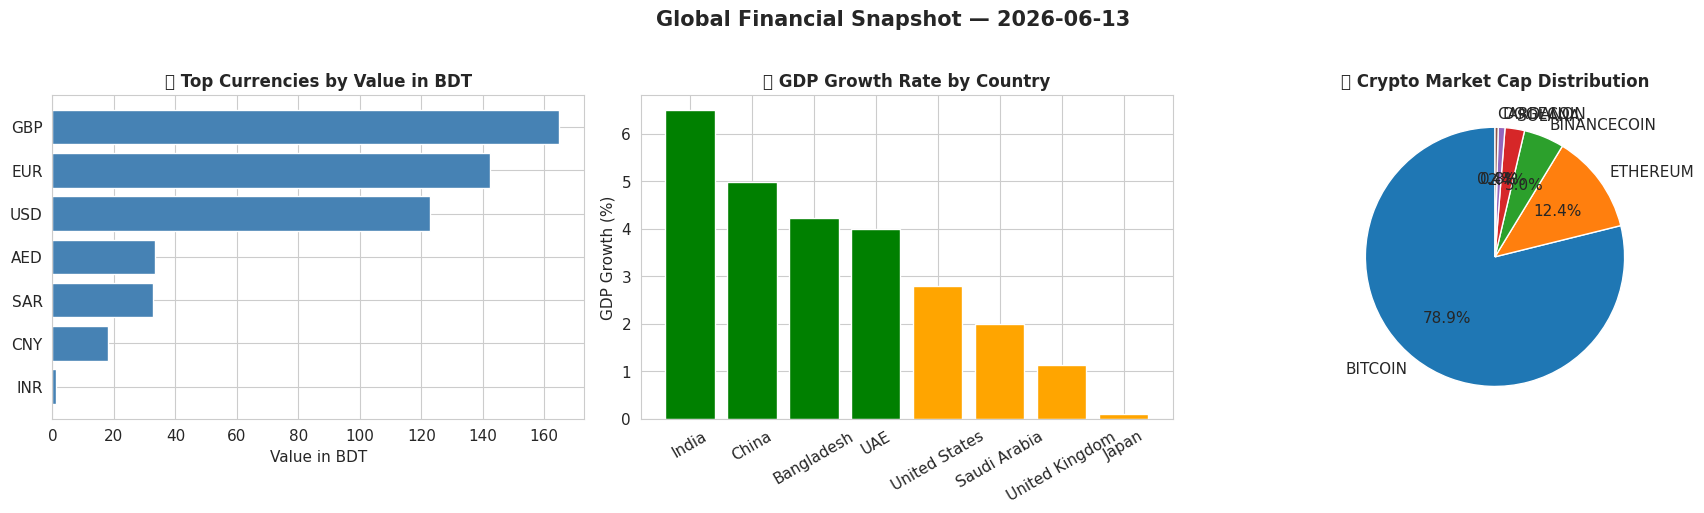

✅ Saved as chart_global_snapshot.png


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: Top currencies by value in BDT
chart_data1 = master_df.dropna(subset=['value_in_bdt']).sort_values('value_in_bdt', ascending=False).head(7)
axes[0].barh(chart_data1['currency'], chart_data1['value_in_bdt'], color='steelblue')
axes[0].set_title('💱 Top Currencies by Value in BDT', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Value in BDT')
axes[0].invert_yaxis()

# Subplot 2: GDP growth by country
chart_data2 = master_df.dropna(subset=['gdp_growth_pct']).sort_values('gdp_growth_pct', ascending=False)
colors_gdp = ['green' if x >= 3 else 'orange' if x >= 0 else 'red' for x in chart_data2['gdp_growth_pct']]
axes[1].bar(chart_data2['country'], chart_data2['gdp_growth_pct'], color=colors_gdp)
axes[1].set_title('📈 GDP Growth Rate by Country', fontsize=12, fontweight='bold')
axes[1].set_ylabel('GDP Growth (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(0, color='black', linewidth=0.5)

# Subplot 3: Crypto market cap distribution
chart_data3 = crypto_df.sort_values('market_cap_billions', ascending=False)
axes[2].pie(chart_data3['market_cap_billions'], labels=chart_data3['coin'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('🪙 Crypto Market Cap Distribution', fontsize=12, fontweight='bold')

plt.suptitle(f'Global Financial Snapshot — {today}', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_global_snapshot.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved as chart_global_snapshot.png")

In [27]:
# ============================================
# 📈 STOCK MARKET DATA — Alpha Vantage API
# ============================================

from google.colab import userdata

# Securely load the API key from Colab Secrets (NOT hardcoded!)
ALPHA_VANTAGE_KEY = userdata.get('ALPHA_VANTAGE_KEY')

print("✅ API key loaded securely from Colab Secrets")
print(f"🔐 Key starts with: {ALPHA_VANTAGE_KEY[:4]}...{ALPHA_VANTAGE_KEY[-2:]} (hidden for safety)")

✅ API key loaded securely from Colab Secrets
🔐 Key starts with: VW6U...ZS (hidden for safety)


In [28]:
# Stocks we want to track (mix of US tech + financial sector + bank-relevant)
stocks_to_track = {
    'AAPL': 'Apple',
    'MSFT': 'Microsoft',
    'GOOGL': 'Alphabet (Google)',
    'AMZN': 'Amazon',
    'NVDA': 'NVIDIA',
    'TSLA': 'Tesla',
}

stock_rows = []

print("📊 Fetching stock market data...\n")

for symbol, name in stocks_to_track.items():
    # Alpha Vantage's GLOBAL_QUOTE endpoint gives current stock data
    stock_url = "https://www.alphavantage.co/query"
    stock_params = {
        'function': 'GLOBAL_QUOTE',
        'symbol': symbol,
        'apikey': ALPHA_VANTAGE_KEY
    }

    try:
        response = requests.get(stock_url, params=stock_params, timeout=10)
        stock_data = response.json()

        if 'Global Quote' in stock_data and stock_data['Global Quote']:
            quote = stock_data['Global Quote']
            stock_rows.append({
                'symbol': symbol,
                'company': name,
                'price_usd': float(quote.get('05. price', 0)),
                'change_pct': float(quote.get('10. change percent', '0%').replace('%', '')),
                'volume': int(quote.get('06. volume', 0)),
                'previous_close': float(quote.get('08. previous close', 0)),
                'collected_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
            })
            print(f"  ✅ {symbol} — {name}")
        else:
            print(f"  ⚠️  {symbol} — No data (likely rate limit hit)")

    except Exception as e:
        print(f"  ❌ {symbol} — Error: {e}")

print(f"\n✅ Pulled data for {len(stock_rows)} stocks")

📊 Fetching stock market data...

  ✅ AAPL — Apple
  ⚠️  MSFT — No data (likely rate limit hit)
  ⚠️  GOOGL — No data (likely rate limit hit)
  ⚠️  AMZN — No data (likely rate limit hit)
  ⚠️  NVDA — No data (likely rate limit hit)
  ⚠️  TSLA — No data (likely rate limit hit)

✅ Pulled data for 1 stocks


In [29]:
# Convert to DataFrame
stocks_df = pd.DataFrame(stock_rows)

# Add a BDT price column (using usd_to_bdt from earlier — data integration!)
stocks_df['price_bdt'] = (stocks_df['price_usd'] * usd_to_bdt).round(2)

# Round numbers nicely
stocks_df['price_usd'] = stocks_df['price_usd'].round(2)
stocks_df['change_pct'] = stocks_df['change_pct'].round(2)

# Sort by absolute change percentage (biggest movers first)
stocks_df['abs_change'] = stocks_df['change_pct'].abs()
stocks_df = stocks_df.sort_values('abs_change', ascending=False).drop('abs_change', axis=1).reset_index(drop=True)

print("📈 Stock Market Snapshot (sorted by biggest movers)\n")
stocks_df[['symbol', 'company', 'price_usd', 'price_bdt', 'change_pct', 'volume']]

📈 Stock Market Snapshot (sorted by biggest movers)



,symbol,company,price_usd,price_bdt,change_pct,volume
0,AAPL,Apple,291.13,35796.9,-1.52,38784789


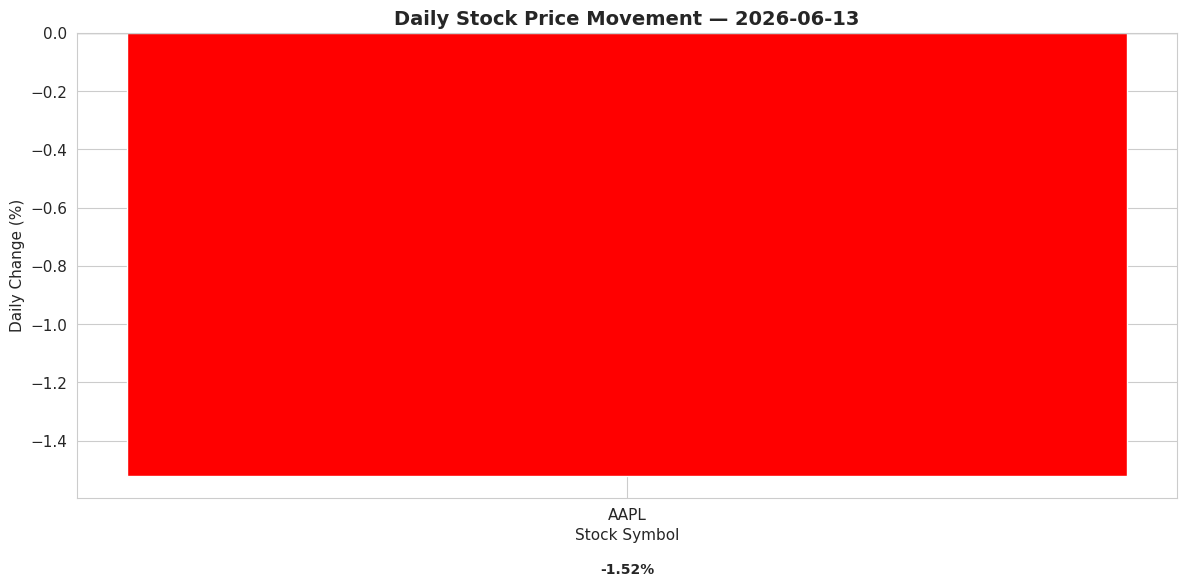

✅ Saved as chart_stocks.png


In [30]:
plt.figure(figsize=(12, 6))

# Color bars by gain/loss
colors = ['green' if x >= 0 else 'red' for x in stocks_df['change_pct']]
bars = plt.bar(stocks_df['symbol'], stocks_df['change_pct'], color=colors)

plt.title(f'Daily Stock Price Movement — {today}', fontsize=14, fontweight='bold')
plt.ylabel('Daily Change (%)')
plt.xlabel('Stock Symbol')
plt.axhline(0, color='black', linewidth=0.8)

# Add labels on top of bars
for bar, pct in zip(bars, stocks_df['change_pct']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (0.1 if height >= 0 else -0.3),
             f'{pct:+.2f}%', ha='center', va='bottom' if height >= 0 else 'top',
             fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('chart_stocks.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved as chart_stocks.png")

In [31]:
# Add the new data sources to your existing Google Sheet
print("📤 Adding new data sources to Google Sheets...\n")

upload_to_sheet(crypto_df, 'Crypto_Markets')
upload_to_sheet(economy_df, 'Economic_Indicators')
upload_to_sheet(stocks_df, 'Stock_Markets')
upload_to_sheet(master_df, 'Unified_Snapshot')

print(f"\n🎉 ALL FOUR DATA SOURCES NOW IN GOOGLE SHEETS!")
print(f"🔗 https://docs.google.com/spreadsheets/d/{spreadsheet.id}")

📤 Adding new data sources to Google Sheets...

  ✅ Uploaded: Crypto_Markets
  ✅ Uploaded: Economic_Indicators
  ✅ Uploaded: Stock_Markets
  ✅ Uploaded: Unified_Snapshot

🎉 ALL FOUR DATA SOURCES NOW IN GOOGLE SHEETS!
🔗 https://docs.google.com/spreadsheets/d/1vlj-7M_sk9VlGYSxBB1pttxUVtv5y3kWm54KupAr9dI
